# MÔ HÌNH 2 (NÂNG CAO): BiLSTM + Multi-Head Attention + ELMo

## Cải tiến so với bản GloVe:

| # | Cải tiến | Tác dụng |
|---|---|---|
| 1 | **ELMo Embedding** thay GloVe | Contextual embedding, cùng từ khác ngữ cảnh → vector khác |
| 2 | Multi-Head Attention (4 heads) | Capture nhiều pattern cùng lúc |
| 3 | Focal Loss + Label Smoothing | Xử lý class imbalance + giảm overfit |
| 4 | EDA nâng cao (4 phép + Synonym) | Tăng data đa dạng hơn |
| 5 | Synthetic templates mở rộng (5 chiều pattern) | Tránh học vẹt template cố định |
| 6 | AI-generated sentences | Câu được sinh thêm cho các class yếu |
| 7 | TF-IDF Leakage Filter | Tự động loại câu trùng train/test |
| 8 | AdamW + Cosine Annealing | Optimizer & scheduler tốt hơn |
| 9 | Dropout 0.5 + Weight decay | Giảm overfitting |


In [1]:
# ===== CÀI ĐẶT DEPENDENCIES =====
import subprocess, sys

# Bước 1: Cài torch GPU TRƯỚC (tránh allennlp đè lên)
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'torch', 'torchvision', 'torchaudio',
                '--index-url', 'https://download.pytorch.org/whl/cu124',
                '-q'], check=True)

# Bước 2: Cài allennlp SAU, --no-deps để không đè torch
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'allennlp', '--no-deps', '-q'], check=True)

# Bước 3: Cài nltk + sklearn
subprocess.run([sys.executable, '-m', 'pip', 'install', 'nltk', '-q'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scikit-learn', '-q'], check=True)

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ===== IMPORTS =====
import numpy as np
import pandas as pd
import re
import random
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import wordnet
from allennlp.modules.elmo import Elmo, batch_to_ids

# ===== Verify GPU =====
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
else:
    print('❌ Vẫn đang CPU — restart kernel rồi chạy lại cell này!')

# ===== Reproducibility =====
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print("✓ Tất cả dependencies đã sẵn sàng!")


[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
c:\Users\xuand\miniconda3\envs\unconscious\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\xuand\miniconda3\envs\unconscious\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


CUDA available : True
GPU            : NVIDIA RTX 3500 Ada Generation Laptop GPU
VRAM           : 12.0 GB
Device: cuda
✓ Tất cả dependencies đã sẵn sàng!


c:\Users\xuand\miniconda3\envs\unconscious\lib\site-packages\fairscale\experimental\nn\offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
c:\Users\xuand\miniconda3\envs\unconscious\lib\site-packages\fairscale\experimental\nn\offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


## 1. Load ELMo Weights

In [2]:
# ==========================================
#         LOAD ELMo
# ==========================================
import urllib.request

ELMO_OPTIONS = 'https://allennlp.s3.amazonaws.com/models/elmo/2x4096_512_2048cnn_2xhighway/elmo_2x4096_512_2048cnn_2xhighway_options.json'
ELMO_WEIGHTS = 'https://allennlp.s3.amazonaws.com/models/elmo/2x4096_512_2048cnn_2xhighway/elmo_2x4096_512_2048cnn_2xhighway_weights.hdf5'

os.makedirs('data/elmo', exist_ok=True)

if not os.path.exists('data/elmo/elmo_options.json'):
    print('Downloading ELMo options...')
    urllib.request.urlretrieve(ELMO_OPTIONS, 'data/elmo/elmo_options.json')
    print('✓ Options downloaded')

if not os.path.exists('data/elmo/elmo_weights.hdf5'):
    print('Downloading ELMo weights (~360MB)...')
    urllib.request.urlretrieve(ELMO_WEIGHTS, 'data/elmo/elmo_weights.hdf5')
    print('✓ Weights downloaded')

elmo = Elmo(
    options_file='data/elmo/elmo_options.json',
    weight_file='data/elmo/elmo_weights.hdf5',
    num_output_representations=1,
    dropout=0.0
).to(device)

ELMO_DIM = 1024
print(f'✓ ELMo loaded! Output dim: {ELMO_DIM}')


✓ ELMo loaded! Output dim: 1024


## 2. Load & Tiền xử lý dữ liệu TREC

In [3]:
# ==========================================
#         LOAD TREC DATASET
# ==========================================
def load_trec_data():
    train_path = r'data/train_5500.label.txt'
    test_path  = r'data/TREC_10.label.txt'
    def parse_file(path):
        texts, labels = [], []
        with open(path, 'r', encoding='latin-1') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                label_full, text = line.split(' ', 1)
                texts.append(text)
                labels.append(label_full.split(':')[0])
        return texts, labels
    print('Loading TREC dataset...')
    X_train, y_train = parse_file(train_path)
    X_test,  y_test  = parse_file(test_path)
    print(f'Train: {len(X_train)} | Test: {len(X_test)}')
    return X_train, y_train, X_test, y_test

#tạo đặc trưng thủ công 
def preprocess_text(text):
    if re.search(r'\b[A-Z]{2,}\b', text):
        #Bẫy viết tắt (__HAS_ACRONYM__):
        text = '__HAS_ACRONYM__ ' + text
        #Nó dùng Regex (\b[A-Z]{2,}\b) để tìm các từ viết hoa toàn bộ (ví dụ: "NASA", "USA")
    abbr_kws = ['stand for', 'short for', 'stands for', 'abbreviation',
                'acronym', 'mean by', 'expand', 'full form', 'initials',
                'spell out', 'long form', 'refers to in full']
    
    #Ông liệt kê một danh sách abbr_kws (như "stand for", "abbreviation"...).

#Nếu câu hỏi chứa các từ này (ví dụ: "What does AI stand for?"), nó lại gắn thêm một tag nữa.
    if any(kw in text.lower() for kw in abbr_kws):
        text = '__ABBR_PATTERN__ ' + text
    text = text.lower()
    #Đưa về chữ thường để giảm độ phức tạp (ví dụ: "What" và "what" là như nhau).
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    #Xóa sạch các ký tự đặc biệt (chấm, phẩy, hỏi chấm...). Chỉ giữ lại chữ cái và số.
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_trec_data()
X_train_raw = [preprocess_text(q) for q in X_train_raw]
X_test_raw  = [preprocess_text(q) for q in X_test_raw]
print(f'\nVí dụ:')
for x, y in zip(X_train_raw[:3], y_train_raw[:3]):
    print(f'  [{y}] {x}')


Loading TREC dataset...
Train: 5452 | Test: 500

Ví dụ:
  [DESC] how did serfdom develop in and then leave russia
  [ENTY] what films featured the character popeye doyle
  [DESC] how can i find a list of celebrities real names


In [4]:
# ==========================================
#         LABEL ENCODING + SPLIT
# ==========================================
label_map   = {'ABBR': 0, 'DESC': 1, 'ENTY': 2, 'HUM': 3, 'LOC': 4, 'NUM': 5}
label_names = ['ABBR', 'DESC', 'ENTY', 'HUM', 'LOC', 'NUM']
y_train_enc = np.array([label_map[l] for l in y_train_raw])
y_test_enc  = np.array([label_map[l] for l in y_test_raw])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_enc,
    test_size=0.15, random_state=SEED, stratify=y_train_enc)
print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test_raw)}')

unique, counts = np.unique(y_train, return_counts=True)
print('\nPhân bổ lớp (train):')
for u, c in zip(unique, counts):
    print(f'  {label_names[u]}: {c}')


Train: 4634 | Val: 818 | Test: 500

Phân bổ lớp (train):
  ABBR: 73
  DESC: 988
  ENTY: 1062
  HUM: 1039
  LOC: 710
  NUM: 762


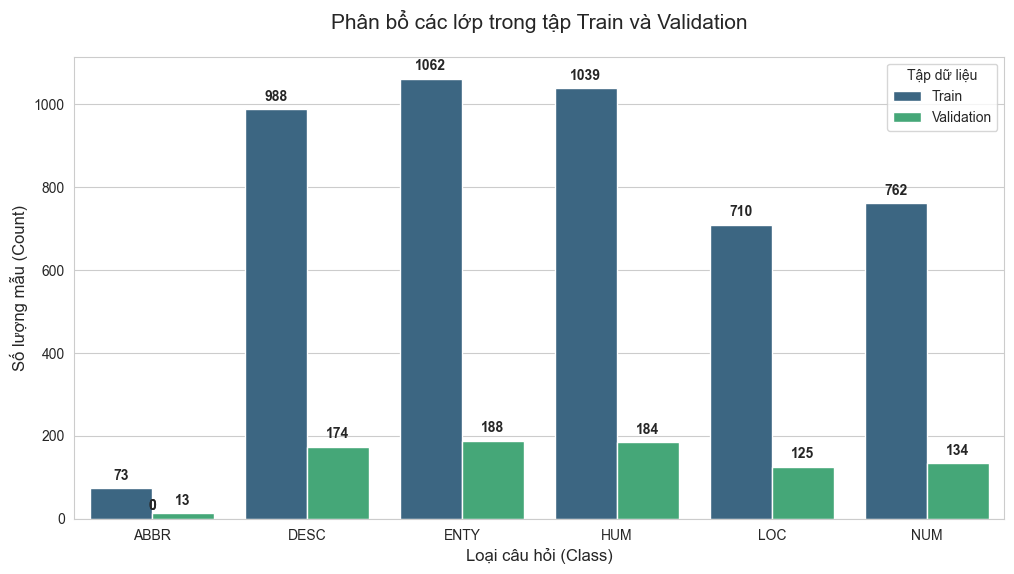

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Chuẩn bị dữ liệu để vẽ
def get_counts(y, name):
    unique, counts = np.unique(y, return_counts=True)
    return pd.DataFrame({
        'Class': [label_names[u] for u in unique],
        'Count': counts,
        'Dataset': name
    })

df_train = get_counts(y_train, 'Train')
df_val = get_counts(y_val, 'Validation')
df_plot = pd.concat([df_train, df_val])

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=df_plot, x='Class', y='Count', hue='Dataset', palette='viridis')

# Thêm con số cụ thể trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title('Phân bổ các lớp trong tập Train và Validation', fontsize=15, pad=20)
plt.xlabel('Loại câu hỏi (Class)', fontsize=12)
plt.ylabel('Số lượng mẫu (Count)', fontsize=12)
plt.legend(title='Tập dữ liệu')
plt.show()

## 3. Data Augmentation (EDA + Synthetic mở rộng + Leakage Filter)

In [6]:
# ==========================================
#    DATA AUGMENTATION - NÂNG CAO
# ==========================================

# ── 4 phép EDA ──
def random_swap(words, n=1):
    new_words = words.copy()
    for _ in range(n):
        if len(new_words) < 2: break
        i, j = random.sample(range(len(new_words)), 2)
        new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def random_delete(words, p=0.1):
    if len(words) <= 2: return words
    new_words = [w for w in words if random.random() > p]
    return new_words if new_words else [random.choice(words)]

def random_insert(words, n=1):
    new_words = words.copy()
    for _ in range(n):
        if not new_words: break
        new_words.insert(random.randint(0, len(new_words)), random.choice(new_words))
    return new_words

def synonym_replace(words, n=1):
    new_words = words.copy()
    indices = list(range(len(new_words)))
    random.shuffle(indices)
    replaced = 0
    for i in indices:
        syns = wordnet.synsets(new_words[i])
        if syns:
            syn_word = syns[0].lemmas()[0].name().replace('_', ' ')
            if syn_word.lower() != new_words[i].lower():
                new_words[i] = syn_word
                replaced += 1
        if replaced >= n: break
    return new_words

def augment_text(text, num_aug=4):
    words = text.split()
    augmented = []
    ops = ['swap', 'delete', 'insert', 'synonym', 'combo']
    for i in range(num_aug):
        op = ops[i % len(ops)]
        if op == 'swap':
            nw = random_swap(words, n=max(1, len(words)//5))
        elif op == 'delete':
            nw = random_delete(words, p=0.15)
        elif op == 'insert':
            nw = random_insert(words, n=1)
        elif op == 'synonym':
            nw = synonym_replace(words, n=max(1, len(words)//4))
        else:
            nw = random_swap(words, n=1)
            nw = random_insert(nw, n=1)
            nw = random_delete(nw, p=0.1)
        augmented.append(' '.join(nw))
    return augmented

# ── Synthetic ABBR — 5 chiều pattern ──
ABBR_TEMPLATES = [
    # Chiều 1: Câu hỏi trực tiếp
    "what does {} stand for",
    "what is {} short for",
    "{} stands for what",
    "what does the acronym {} mean",
    # Chiều 2: Câu hỏi lịch sự/gián tiếp
    "could you tell me what {} means",
    "do you know what {} stands for",
    "i wonder what {} is short for",
    "can you tell me what {} stands for",
    # Chiều 3: Câu mệnh lệnh
    "expand {}",
    "spell out {}",
    "give me the full form of {}",
    "define the abbreviation {}",
    "tell me the full form of {}",
    # Chiều 4: Cấu trúc đảo
    "{} is an abbreviation for what",
    "{} expands to what",
    "{} is short for what",
    "what is the expansion of {}",
    "what is {} an abbreviation for",
    # Chiều 5: Có ngữ cảnh
    "in computing what does {} stand for",
    "what is the full name of {}",
    "what do the initials {} stand for",
    "how do you expand {}",
    "what is the long form of {}",
]
ACRONYMS = [
    "NASA", "FBI", "CIA", "NATO", "DNA", "AIDS", "RADAR",
    "SCUBA", "WHO", "IMF", "UFO", "IQ", "GPA", "MBA",
    "GPU", "USB", "GPS", "HTML", "CEO", "UK",
    "AC", "DC", "AM", "FM", "TV",
    # Entity mới không có trong tập cũ
    "HVAC", "SONAR", "LASER", "TASER", "JPEG", "MPEG",
    "INTERPOL", "UNICEF", "OPEC", "SWAT", "CAPTCHA",
    "UNESCO", "ICU", "NICU", "VPN", "PhD", "GDP",
    "SMS", "DIY", "SQL", "API", "PDF", "URL", "ATM",
]
synthetic_abbr = [preprocess_text(t.format(a)) for a in ACRONYMS for t in ABBR_TEMPLATES]
print(f'Synthetic ABBR: {len(synthetic_abbr)} câu')

# ── Synthetic ENTY ──
ENTY_TEMPLATES = [
    "what kind of animal is {}",
    "what type of food is {}",
    "what is {} made of",
    "what kind of sport is {}",
    "what is a {}",
    "what type of creature is {}",
    "what kind of plant is {}",
    "what is the name of this {}",
    "what category does {} belong to",
    "what type of material is {}",
]
ENTY_ENTITIES = [
    "dolphin", "eagle", "salmon", "cobra", "panda", "jaguar", "falcon",
    "sushi", "pasta", "curry", "tofu", "lasagna", "kebab", "ramen",
    "soccer", "rugby", "cricket", "badminton", "polo", "lacrosse",
    "oak", "cactus", "bamboo", "orchid", "maple", "fern", "sequoia",
    "diamond", "granite", "copper", "titanium", "quartz", "obsidian",
    "platypus", "chameleon", "axolotl", "narwhal",
]
synthetic_enty = [preprocess_text(t.format(e)) for e in ENTY_ENTITIES for t in ENTY_TEMPLATES]
print(f'Synthetic ENTY: {len(synthetic_enty)} câu')

# ── Synthetic LOC ──
LOC_TEMPLATES = [
    "where is {} located",
    "what country is {} in",
    "where can you find {}",
    "in which continent is {}",
    "what city is {} in",
    "where is the {} situated",
    "in which country is {}",
    "what is the location of {}",
]
LOC_ENTITIES = [
    "mount everest", "the amazon river", "the sahara desert",
    "the great wall", "the eiffel tower", "the colosseum",
    "the nile river", "the grand canyon", "the great barrier reef",
    "machu picchu", "angkor wat", "the taj mahal",
    "the amazon rainforest", "victoria falls", "the dead sea",
    "mount kilimanjaro", "the trevi fountain", "the kremlin",
]
synthetic_loc = [preprocess_text(t.format(l)) for l in LOC_ENTITIES for t in LOC_TEMPLATES]
print(f'Synthetic LOC : {len(synthetic_loc)} câu')

# ── AI-Generated sentences ──
ai_generated = {
    'ABBR': [
        "what is hvac short for",
        "jpeg is short for what exactly",
        "please define the acronym sonar",
        "what do the letters taser represent",
        "give me the expansion of mpeg",
        "what does interpol stand for",
        "unicef is an abbreviation for what",
        "what is the full name of opec",
        "expand the acronym swat",
        "what does captcha mean",
        "what is unesco short for",
        "can you tell me what icu stands for",
        "nicu stands for what exactly",
        "what is the long form of faq",
        "what does sql stand for",
        "api is short for what",
        "what does vpn stand for in networking",
        "phd is an abbreviation for what",
        "what is gdp short for in economics",
        "sms stands for what in telecommunications",
        "what does diy mean",
        "could you give me the long form of wi fi",
        "what is pdf an abbreviation for",
        "url expands to what",
        "ram means what in computers",
        "what does atm stand for in banking",
        "ceo is short for what",
        "faq stands for what",
        "what do the initials cia stand for",
        "how do you expand phd",
    ],
    'ENTY': [
        "what type of creature is a bat",
        "what kind of fish is a shark",
        "what is the material of glass",
        "what type of metal is gold",
        "what kind of tree is a redwood",
        "what is silk made from",
        "what type of bird is a penguin",
        "what kind of reptile is a gecko",
        "what is bronze an alloy of",
        "what type of sport is fencing",
        "what kind of flower is a rose",
        "what is leather made from",
        "what type of animal is a whale",
        "what kind of insect is a butterfly",
        "what is concrete made of",
        "what type of fruit is a tomato",
        "what kind of dance is tango",
        "what is porcelain made from",
        "what type of stone is marble",
        "what kind of music is jazz",
        "what is a mammal",
        "what type of weapon is a crossbow",
        "what kind of vehicle is a submarine",
        "what is nylon made of",
        "what type of instrument is a violin",
        "what kind of art is origami",
        "what is a herbivore",
        "what type of cloud is a cumulus",
        "what kind of currency is the euro",
        "what is a fossil",
    ],
    'LOC': [
        "where is the amazon river located",
        "what country is the sahara desert in",
        "where is mount fuji situated",
        "in which country is the louvre museum",
        "where is the great barrier reef located",
        "what continent is egypt in",
        "where is the statue of liberty",
        "in which city is the colosseum located",
        "where is the dead sea",
        "what country is machu picchu in",
        "where is niagara falls located",
        "in which country is angkor wat",
        "where is the victoria lake",
        "what country is the acropolis in",
        "where is stonehenge located",
        "in which continent is brazil",
        "where is the sahara located",
        "what country is the parthenon in",
        "where is the amazon rainforest",
        "in which city is big ben located",
        "where is mount kilimanjaro",
        "what country is the sphinx in",
        "where is the kremlin located",
        "in which country is the forbidden city",
        "where is the opera house in sydney",
        "what continent is new zealand in",
        "where is the trevi fountain",
        "in which country is the pyramids of giza",
        "where is the black forest located",
        "what country is the fjords in",
    ],
}
for k, v in ai_generated.items():
    print(f'AI-generated {k}: {len(v)} câu')


Synthetic ABBR: 1127 câu
Synthetic ENTY: 370 câu
Synthetic LOC : 144 câu
AI-generated ABBR: 30 câu
AI-generated ENTY: 30 câu
AI-generated LOC: 30 câu


### máy đo độ tương đồng câu 

In [7]:
# ==========================================
#    LEAKAGE FILTER + AUGMENT PIPELINE
# ==========================================

# Xây dựng TF-IDF để check leakage
check_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
check_vectorizer.fit(X_test_raw + X_train)
test_vectors = check_vectorizer.transform(X_test_raw)
# TF-IDF chuyển mỗi câu thành vector số. ngram_range=(1,2) 
# nghĩa là nó đọc cả đơn từ ("what") lẫn cặp từ ("stand for") — nhạy hơn với pattern ABBR.
def is_leaking(new_text, threshold=0.85):
    new_vec = check_vectorizer.transform([new_text])
    sim = cosine_similarity(new_vec, test_vectors)
    return sim.max() >= threshold
# Câu mới được chuyển thành vector
# → đo cosine similarity với toàn bộ 500 câu test. Nếu giống bất kỳ câu nào ≥ 85% → vứt bỏ
def add_safe(texts, labels, X_list, y_list):
    added = 0
    for txt, lbl in zip(texts, labels):
        processed = preprocess_text(txt) if not txt.startswith('__') else txt
        if not is_leaking(processed):
            X_list.append(processed)
            y_list.append(lbl)
            added += 1
    return added

# Khởi tạo train augmented
X_train_aug = list(X_train)
y_train_aug = list(y_train)

# Xóa câu trùng từ train gốc trước
train_vectors = check_vectorizer.transform(X_train_aug)
sim_matrix    = cosine_similarity(test_vectors, train_vectors)
leak_indices  = set()
for i, sims in enumerate(sim_matrix):
    for j in np.where(sims >= 0.95)[0]:
        leak_indices.add(j)

if leak_indices:
    X_train_aug = [t for i, t in enumerate(X_train_aug) if i not in leak_indices]
    y_train_aug = [l for i, l in enumerate(y_train_aug) if i not in leak_indices]
    print(f'Đã xóa {len(leak_indices)} câu trùng từ train gốc')

# Thêm synthetic
n1 = add_safe(synthetic_abbr, [label_map['ABBR']]*len(synthetic_abbr), X_train_aug, y_train_aug)
n2 = add_safe(synthetic_enty, [label_map['ENTY']]*len(synthetic_enty), X_train_aug, y_train_aug)
n3 = add_safe(synthetic_loc,  [label_map['LOC']] *len(synthetic_loc),  X_train_aug, y_train_aug)
print(f'Synthetic thêm được — ABBR: {n1}, ENTY: {n2}, LOC: {n3}')
# Thêm câu tự viết tay (synthetic) và câu do AI sinh ra cho các class yếu
# — nhưng mỗi câu đều phải qua leakage filter trước khi được thêm vào.
# # Thêm AI-generated
for cls_name, sents in ai_generated.items():
    n = add_safe(sents, [label_map[cls_name]]*len(sents), X_train_aug, y_train_aug)
    print(f'AI-generated {cls_name}: +{n}')

# EDA cân bằng class
max_count = pd.Series(y_train_aug).value_counts().max()
for cls_id in range(6):
    cls_texts = [X_train_aug[i] for i, v in enumerate(y_train_aug) if v == cls_id]
    need = max_count - len(cls_texts)
    if need <= 0: continue
    added = 0
    for txt in cls_texts:
        if added >= need: break
        for aug in augment_text(txt, num_aug=5):
            if added >= need: break
            if not is_leaking(aug):
                X_train_aug.append(aug)
                y_train_aug.append(cls_id)
                added += 1

y_train_aug = np.array(y_train_aug)
print(f'\nTrain gốc : {len(X_train)}')
print(f'Sau augment: {len(X_train_aug)}')
print('\nPhân bổ lớp sau augmentation:')
unique_aug, counts_aug = np.unique(y_train_aug, return_counts=True)
for u, c in zip(unique_aug, counts_aug):
    print(f'  {label_names[u]}: {c}')


Đã xóa 14 câu trùng từ train gốc
Synthetic thêm được — ABBR: 1125, ENTY: 370, LOC: 140
AI-generated ABBR: +29
AI-generated ENTY: +30
AI-generated LOC: +29

Train gốc : 4634
Sau augment: 8772

Phân bổ lớp sau augmentation:
  ABBR: 1462
  DESC: 1462
  ENTY: 1462
  HUM: 1462
  LOC: 1462
  NUM: 1462


câu mới ↔ toàn bộ tập test → cosine similarity ≥ 0.85?
→ Có: vứt bỏ
→ Không: giữ lại

 xây dựng một cái "Màng lọc Leakage" bằng TF-IDF và Cosine Similarity.Nó tính toán độ tương đồng giữa câu mới tạo ra (Augmented) và toàn bộ tập Test.Nếu độ giống nhau $\ge 85\%$ (ngưỡng 0.85), vứt bỏ câu đó ngay lập tức. Điều này đảm bảo mô hình phải thực sự "hiểu" chứ không được "nhìn trộm" đáp án.

## 4. Config & Tokenization & ELMo Encoding

In [8]:
# ==========================================
#         CONFIG
# ==========================================
MAX_LEN      = 64
ELMO_DIM     = 1024
HIDDEN_DIM   = 256
NUM_LAYERS   = 2
NUM_HEADS    = 4
DROPOUT      = 0.5
NUM_CLASSES  = 6
BATCH_SIZE   = 32
EPOCHS       = 60
LR           = 5e-4
PATIENCE     = 10
FOCAL_GAMMA  = 3.0
WEIGHT_DECAY = 1e-2


ELMo cho representation tốt ở mức từ, còn BiLSTM học mối quan hệ tuần tự giữa các từ trong câu, Attention giúp model focus vào từ quan trọng nhất thay vì đọc cả câu đều nhau. Ba thành phần bổ trợ nhau — ELMo không "gánh một mình" mà là nền tảng tốt để BiLSTM và Attention phát huy.

In [9]:
# ==========================================
#    TOKENIZE & ELMo ENCODE
# ==========================================
def tokenize(text):
    return text.split()[:MAX_LEN]

def pad_tokens(tokens, maxlen):
    if len(tokens) >= maxlen: return tokens[:maxlen]
    return tokens + ['<pad>'] * (maxlen - len(tokens))
### độn lên cho đủ 64 vì elmo rất cần câu có độ dài 64 để xử lsi song song trên gpu 

X_train_tok = [pad_tokens(tokenize(t), MAX_LEN) for t in X_train_aug]
X_val_tok   = [pad_tokens(tokenize(t), MAX_LEN) for t in X_val]
X_test_tok  = [pad_tokens(tokenize(t), MAX_LEN) for t in X_test_raw]

print(f'Train: {len(X_train_tok)} | Val: {len(X_val_tok)} | Test: {len(X_test_tok)}')
### elmo không đọc từ nhưu glove, nó đọc từng ký tự  nó đọc **từng ký tự** trong từ rồi tổng hợp lại. Nên "NASA
# " → `[N, A, S, A]` → char_ids. Đây là lý do ELMo xử lý được từ lạ/OOV mà GloVe không làm được.
def encode_elmo_batch(token_lists, elmo_model, device, batch_size=64):
    elmo_model.eval()
    all_embeddings = []
    for i in range(0, len(token_lists), batch_size):
        batch    = token_lists[i:i+batch_size]
        char_ids = batch_to_ids(batch).to(device)
        with torch.no_grad():
            emb = elmo_model(char_ids)['elmo_representations'][0]
        all_embeddings.append(emb.cpu())
        if (i // batch_size) % 20 == 0:
            print(f'  Encoded {min(i+batch_size, len(token_lists))}/{len(token_lists)}')
    return torch.cat(all_embeddings, dim=0)

print('\nEncoding Train...')
X_train_emb = encode_elmo_batch(X_train_tok, elmo, device) # làm trước vòng train
print('Encoding Val...')
X_val_emb   = encode_elmo_batch(X_val_tok,   elmo, device)
print('Encoding Test...')
X_test_emb  = encode_elmo_batch(X_test_tok,  elmo, device)
#ELMo được chạy **trước khi training**,
#  kết quả lưu vào RAM. Mỗi epoch sau chỉ đọc từ RAM ra, không chạy ELMo lại.
#  Nếu không làm vậy thì mỗi epoch chạy ELMo 1 lần → **60 epochs × vài phút = cả tiếng đồng hồ**.

print(f'\nTrain: {X_train_emb.shape} | Val: {X_val_emb.shape} | Test: {X_test_emb.shape}')
# Câu text
#   ↓ split() → list từ (tối đa 64)
#   ↓ pad → đúng 64 từ
#   ↓ batch_to_ids → char-level IDs
#   ↓ ELMo → vector 1024/từ
#   ↓ lưu vào RAM
#   → shape (N, 64, 1024) sẵn sàng cho BiLSTM


Train: 8772 | Val: 818 | Test: 500

Encoding Train...
  Encoded 64/8772
  Encoded 1344/8772
  Encoded 2624/8772
  Encoded 3904/8772
  Encoded 5184/8772
  Encoded 6464/8772
  Encoded 7744/8772
Encoding Val...
  Encoded 64/818
Encoding Test...
  Encoded 64/500

Train: torch.Size([8772, 64, 1024]) | Val: torch.Size([818, 64, 1024]) | Test: torch.Size([500, 64, 1024])


Câu text
  ↓ split() → list từ (tối đa 64)
  ↓ pad → đúng 64 từ
  ↓ batch_to_ids → char-level IDs
  ↓ ELMo → vector 1024/từ
  ↓ lưu vào RAM
  → shape (N, 64, 1024) sẵn sàng cho BiLSTM

ELMo đã được train trên hàng tỷ từ ngữ, nó đã nắm vững quy luật ngôn ngữ. Việc em dùng bản pre-trained giúp mô hình của em kế thừa tri thức đó, chỉ cần tập trung học cách phân loại (fine-tune) trên tập dữ liệu TREC nhỏ của mình, vừa nhanh vừa đạt độ chính xác cực cao.

## 5. Dataset & DataLoader

In [10]:
# ==========================================
#         DATASET
# ==========================================
class TRECDataset(Dataset):
    def __init__(self, X_emb, y):
        self.X = X_emb.float() # tensor (N, 64, 102
        self.y = torch.tensor(y, dtype=torch.long)# tensor (N,)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_dataset = TRECDataset(X_train_emb, y_train_aug)
val_dataset   = TRECDataset(X_val_emb,   y_val)
test_dataset  = TRECDataset(X_test_emb,  y_test_enc)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')


Train: 275 batches | Val: 26 | Test: 16


## 6. Kiến trúc BiLSTM + Multi-Head Attention

```
ELMo Embedding (1024) → Input Projection (256) → Dropout
  → BiLSTM 2-layer (512) → LayerNorm
  → Multi-Head Attention (4 heads) → context (512)
  → Dropout → FC (512→256→6)
```


In [11]:
# ==========================================
#    MODEL: BiLSTM + Multi-Head Attention
# ==========================================
class MultiHeadAttentionPool(nn.Module):
    def __init__(self, hidden_dim, num_heads):
        super().__init__()
        self.attn  = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, hidden_dim))
# self.query là 1 vector được học — không phải cố định, nó tự cập nhật qua training.
# Hình dung nó như 1 "câu hỏi" mà Attention dùng để hỏi các từ trong câu.
    def forward(self, lstm_out):
        query = self.query.expand(lstm_out.size(0), -1, -1)
        context, weights = self.attn(query, lstm_out, lstm_out)
        return context.squeeze(1), weights.squeeze(1)
# `expand` — nhân bản query cho đủ batch_size. Nếu batch có 32 câu thì query cũng phải thành 32 bản.

# `self.attn(query, lstm_out, lstm_out)` — đây là lúc Attention hoạt động. 3 tham số là **(Q, K, V)**:
# ```
# Q (Query)  = query vector — "tao đang tìm gì?"
# K (Key)    = lstm_out     — "mỗi từ có gì?"
# V (Value)  = lstm_out     — "nếu match thì lấy thông tin này"

# ====Layer 2======
class BiLSTMAttentionELMo(nn.Module):
    def __init__(self, elmo_dim, hidden_dim, num_classes, num_layers, num_heads, dropout):
        super().__init__()
        self.input_proj = nn.Linear(elmo_dim, hidden_dim)
        self.lstm = nn.LSTM(input_size=hidden_dim, hidden_size=hidden_dim,# nhận vào 256
                            num_layers=num_layers, batch_first=True,# hidden state 256
                            bidirectional=True,# 2 tầng LSTM chồng nhau
                            dropout=dropout if num_layers > 1 else 0.0)# đọc 2 chiều
        lstm_out_dim    = hidden_dim * 2# 256 × 2 = 512
        # ===Layer NORM=== layer 3
        self.layer_norm = nn.LayerNorm(lstm_out_dim)


        # === layer 4==== layer attention 
        self.attention  = MultiHeadAttentionPool(lstm_out_dim, num_heads)
        # nhận (batch, 64, 512) → trả ra (batch, 512)
        self.dropout    = nn.Dropout(dropout)

        # === layer 5 ==== layer classifier
        self.fc = nn.Sequential(
            nn.Linear(lstm_out_dim, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, num_classes)
        )

#         self.fc = nn.Sequential(
#     nn.Linear(512, 256), nn.ReLU(),
#     nn.Dropout(0.5),
#     nn.Linear(256, 6)   # 6 classes
# )


### Forward pass — data chạy qua model như thế nào
    def forward(self, x):# x: (32, 64, 1024)
        x = self.dropout(F.relu(self.input_proj(x)))# → (32, 64, 256)
        lstm_out, _ = self.lstm(x)# → (32, 64, 512)
        lstm_out    = self.layer_norm(lstm_out)# → (32, 64, 512)
        context, weights = self.attention(lstm_out)# → (32, 512)
        return self.fc(self.dropout(context)), weights# → (32, 6)


# (32, 64, 1024)  ← ELMo embedding
#       ↓ Linear
# (32, 64, 256)   ← thu nhỏ
#       ↓ BiLSTM
# (32, 64, 512)   ← mỗi từ hiểu ngữ cảnh 2 chiều
#       ↓ LayerNorm
# (32, 64, 512)   ← chuẩn hóa
#       ↓ Attention
# (32, 512)       ← gộp 64 từ → 1 vector cả câu
#       ↓ FC
# (32, 6)         ← xác suất 6 class

model2 = BiLSTMAttentionELMo( ## khoi tao, truyen tham so vo model 
    elmo_dim=ELMO_DIM, hidden_dim=HIDDEN_DIM, num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=DROPOUT
).to(device)

total = sum(p.numel() for p in model2.parameters())
print(f'Total params: {total:,} | Trainable: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}')
print(model2)


Total params: 4,077,062 | Trainable: 4,077,062
BiLSTMAttentionELMo(
  (input_proj): Linear(in_features=1024, out_features=256, bias=True)
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (attention): MultiHeadAttentionPool(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)


## 7. Focal Loss & Optimizer

In [12]:
# ==========================================
#         FOCAL LOSS + LABEL SMOOTHING
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1, reduction='mean'):
        super().__init__()
        self.gamma = gamma; self.label_smoothing = label_smoothing; self.reduction = reduction
        self.alpha = nn.Parameter(torch.tensor(alpha, dtype=torch.float32), requires_grad=False) if alpha is not None else None

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.alpha,
                               label_smoothing=self.label_smoothing, reduction='none')
        fl   = ((1 - torch.exp(-ce)) ** self.gamma) * ce
        return fl.mean() if self.reduction == 'mean' else fl.sum()

class_counts_arr     = np.bincount(y_train_aug, minlength=NUM_CLASSES).astype(float)
class_weights        = 1.0 / class_counts_arr
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', {label_names[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

criterion2 = FocalLoss(alpha=class_weights_tensor, gamma=FOCAL_GAMMA, label_smoothing=0.1)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer2, T_0=15, T_mult=2, eta_min=1e-6)


Class weights: {'ABBR': '1.000', 'DESC': '1.000', 'ENTY': '1.000', 'HUM': '1.000', 'LOC': '1.000', 'NUM': '1.000'}


C:\Users\xuand\AppData\Local\Temp\ipykernel_3644\2257808786.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.alpha = nn.Parameter(torch.tensor(alpha, dtype=torch.float32), requires_grad=False) if alpha is not None else None


## 8. Training Loop

In [13]:
# ==========================================
#         TRAINING LOOP
# ==========================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs, _ = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct    += (outputs.argmax(1) == y_batch).sum().item()
        total      += X_batch.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            correct    += (outputs.argmax(1) == y_batch).sum().item()
            total      += X_batch.size(0)
    return total_loss / total, correct / total

history2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, patience_count, best_state = 0.0, 0, None

print('=' * 65)
print('  TRAINING: BiLSTM + Multi-Head Attention + ELMo + Focal Loss')
print('=' * 65)
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model2, train_loader, optimizer2, criterion2, device)
    vl_loss, vl_acc = eval_epoch(model2, val_loader,   criterion2, device)
    scheduler2.step()
    history2['train_loss'].append(tr_loss); history2['train_acc'].append(tr_acc)
    history2['val_loss'].append(vl_loss);   history2['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | LR: {optimizer2.param_groups[0]["lr"]:.2e}')
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc; best_state = copy.deepcopy(model2.state_dict())
        patience_count = 0; print(f'  → New best! Val Acc: {best_val_acc:.4f}')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping tại epoch {epoch}. Best val acc: {best_val_acc:.4f}'); break

model2.load_state_dict(best_state)
torch.save(model2.state_dict(), 'model2_bilstm_elmo_best.pt')
print(f'\n✓ Training hoàn thành. Best Val Accuracy: {best_val_acc*100:.2f}%')
print(f'✓ Model saved: model2_bilstm_elmo_best.pt')


  TRAINING: BiLSTM + Multi-Head Attention + ELMo + Focal Loss
Epoch 01/60 | Train Loss: 0.4121 Acc: 0.7120 | Val Loss: 0.3595 Acc: 0.7934 | LR: 4.95e-04
  → New best! Val Acc: 0.7934
Epoch 02/60 | Train Loss: 0.2006 Acc: 0.8828 | Val Loss: 0.2119 Acc: 0.8704 | LR: 4.78e-04
  → New best! Val Acc: 0.8704
Epoch 03/60 | Train Loss: 0.1623 Acc: 0.9085 | Val Loss: 0.1846 Acc: 0.8802 | LR: 4.52e-04
  → New best! Val Acc: 0.8802
Epoch 04/60 | Train Loss: 0.1349 Acc: 0.9258 | Val Loss: 0.2007 Acc: 0.8924 | LR: 4.17e-04
  → New best! Val Acc: 0.8924
Epoch 05/60 | Train Loss: 0.1130 Acc: 0.9406 | Val Loss: 0.2072 Acc: 0.8924 | LR: 3.75e-04
Epoch 06/60 | Train Loss: 0.0991 Acc: 0.9484 | Val Loss: 0.1969 Acc: 0.9046 | LR: 3.28e-04
  → New best! Val Acc: 0.9046
Epoch 07/60 | Train Loss: 0.0847 Acc: 0.9600 | Val Loss: 0.1823 Acc: 0.8973 | LR: 2.77e-04
Epoch 08/60 | Train Loss: 0.0696 Acc: 0.9661 | Val Loss: 0.1853 Acc: 0.9108 | LR: 2.24e-04
  → New best! Val Acc: 0.9108
Epoch 09/60 | Train Loss: 0.06

## 9. Learning Curves

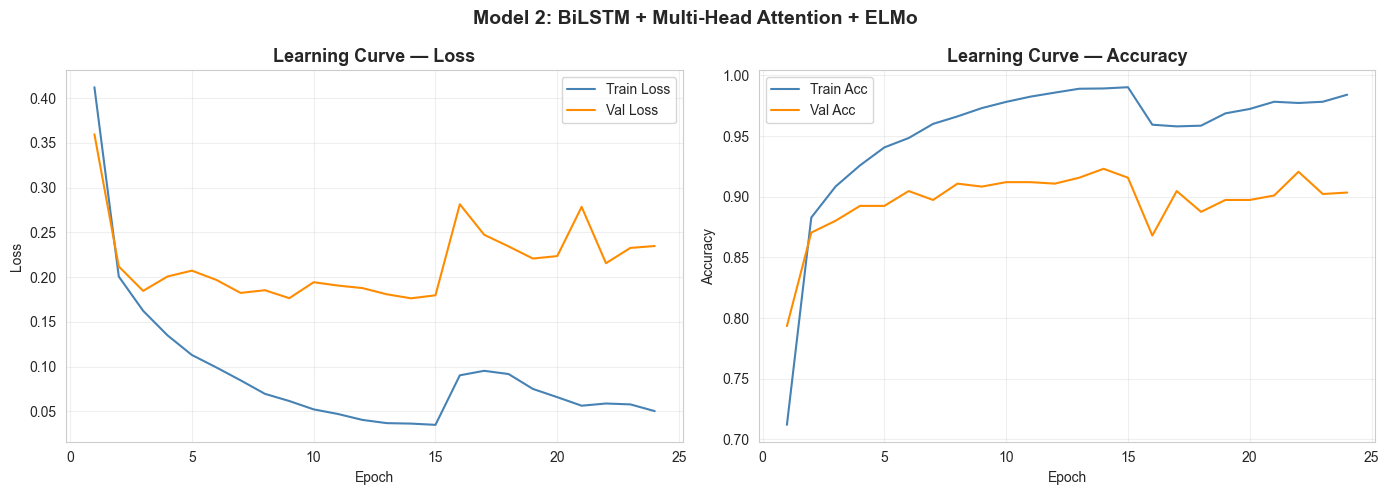

In [14]:
# ==========================================
#         LEARNING CURVES
# ==========================================
epochs_ran = len(history2['train_loss'])
x_axis     = range(1, epochs_ran + 1)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_axis, history2['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(x_axis, history2['val_loss'],   label='Val Loss',   color='darkorange')
axes[0].set_title('Learning Curve — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(x_axis, history2['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(x_axis, history2['val_acc'],   label='Val Acc',   color='darkorange')
axes[1].set_title('Learning Curve — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Model 2: BiLSTM + Multi-Head Attention + ELMo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Đánh giá trên Test Set

In [15]:
# ==========================================
#         EVALUATION
# ==========================================
model2.eval()
y_true2, y_pred2 = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs, _ = model2(X_batch.to(device))
        y_pred2.extend(outputs.argmax(1).cpu().numpy())
        y_true2.extend(y_batch.numpy())

y_true2 = np.array(y_true2); y_pred2 = np.array(y_pred2)
acc2          = accuracy_score(y_true2, y_pred2)
f1_macro2     = f1_score(y_true2, y_pred2, average='macro')
f1_weighted2  = f1_score(y_true2, y_pred2, average='weighted')
f1_per_class2 = f1_score(y_true2, y_pred2, average=None)
cm2           = confusion_matrix(y_true2, y_pred2)

print('=' * 60)
print('KẾT QUẢ MODEL 2: BiLSTM + Multi-Head Attention + ELMo')
print('=' * 60)
print(f'Test Accuracy       : {acc2:.4f} ({acc2*100:.2f}%)')
print(f'F1 Score (Macro)    : {f1_macro2:.4f}')
print(f'F1 Score (Weighted) : {f1_weighted2:.4f}')
print()
print('CLASSIFICATION REPORT:')
print(classification_report(y_true2, y_pred2, target_names=label_names, digits=4))
print('Confusion Matrix:'); print(cm2)


KẾT QUẢ MODEL 2: BiLSTM + Multi-Head Attention + ELMo
Test Accuracy       : 0.9580 (95.80%)
F1 Score (Macro)    : 0.9640
F1 Score (Weighted) : 0.9575

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        ABBR     1.0000    1.0000    1.0000         9
        DESC     0.9375    0.9783    0.9574       138
        ENTY     0.9529    0.8617    0.9050        94
         HUM     0.9412    0.9846    0.9624        65
         LOC     0.9875    0.9753    0.9814        81
         NUM     0.9737    0.9823    0.9780       113

    accuracy                         0.9580       500
   macro avg     0.9655    0.9637    0.9640       500
weighted avg     0.9583    0.9580    0.9575       500

Confusion Matrix:
[[  9   0   0   0   0   0]
 [  0 135   2   1   0   0]
 [  0   7  81   3   1   2]
 [  0   0   1  64   0   0]
 [  0   0   1   0  79   1]
 [  0   2   0   0   0 111]]


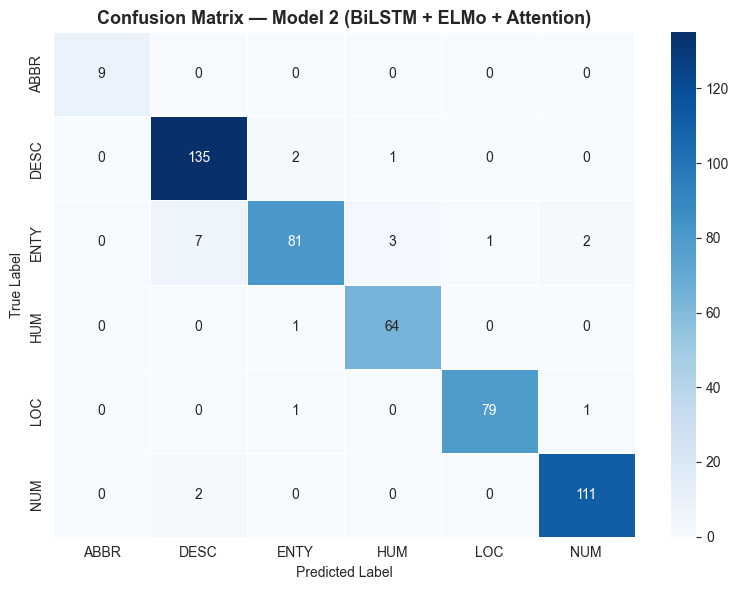

In [16]:
# ==========================================
#         CONFUSION MATRIX
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, linewidths=0.5)
plt.title('Confusion Matrix — Model 2 (BiLSTM + ELMo + Attention)', fontsize=13, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('model2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Số tham số mô hình

In [17]:
print('=' * 55)
print('THỐNG KÊ SỐ THAM SỐ MODEL 2')
print('=' * 55)
for name, param in model2.named_parameters():
    print(f'{name:45s} | {str(list(param.shape)):20s} | {param.numel():>10,}')
print('-' * 55)
print(f'TOTAL     : {sum(p.numel() for p in model2.parameters()):>10,}')
print(f'TRAINABLE : {sum(p.numel() for p in model2.parameters() if p.requires_grad):>10,}')


THỐNG KÊ SỐ THAM SỐ MODEL 2
input_proj.weight                             | [256, 1024]          |    262,144
input_proj.bias                               | [256]                |        256
lstm.weight_ih_l0                             | [1024, 256]          |    262,144
lstm.weight_hh_l0                             | [1024, 256]          |    262,144
lstm.bias_ih_l0                               | [1024]               |      1,024
lstm.bias_hh_l0                               | [1024]               |      1,024
lstm.weight_ih_l0_reverse                     | [1024, 256]          |    262,144
lstm.weight_hh_l0_reverse                     | [1024, 256]          |    262,144
lstm.bias_ih_l0_reverse                       | [1024]               |      1,024
lstm.bias_hh_l0_reverse                       | [1024]               |      1,024
lstm.weight_ih_l1                             | [1024, 512]          |    524,288
lstm.weight_hh_l1                             | [1024, 256]          |

## 12. Attention Visualization

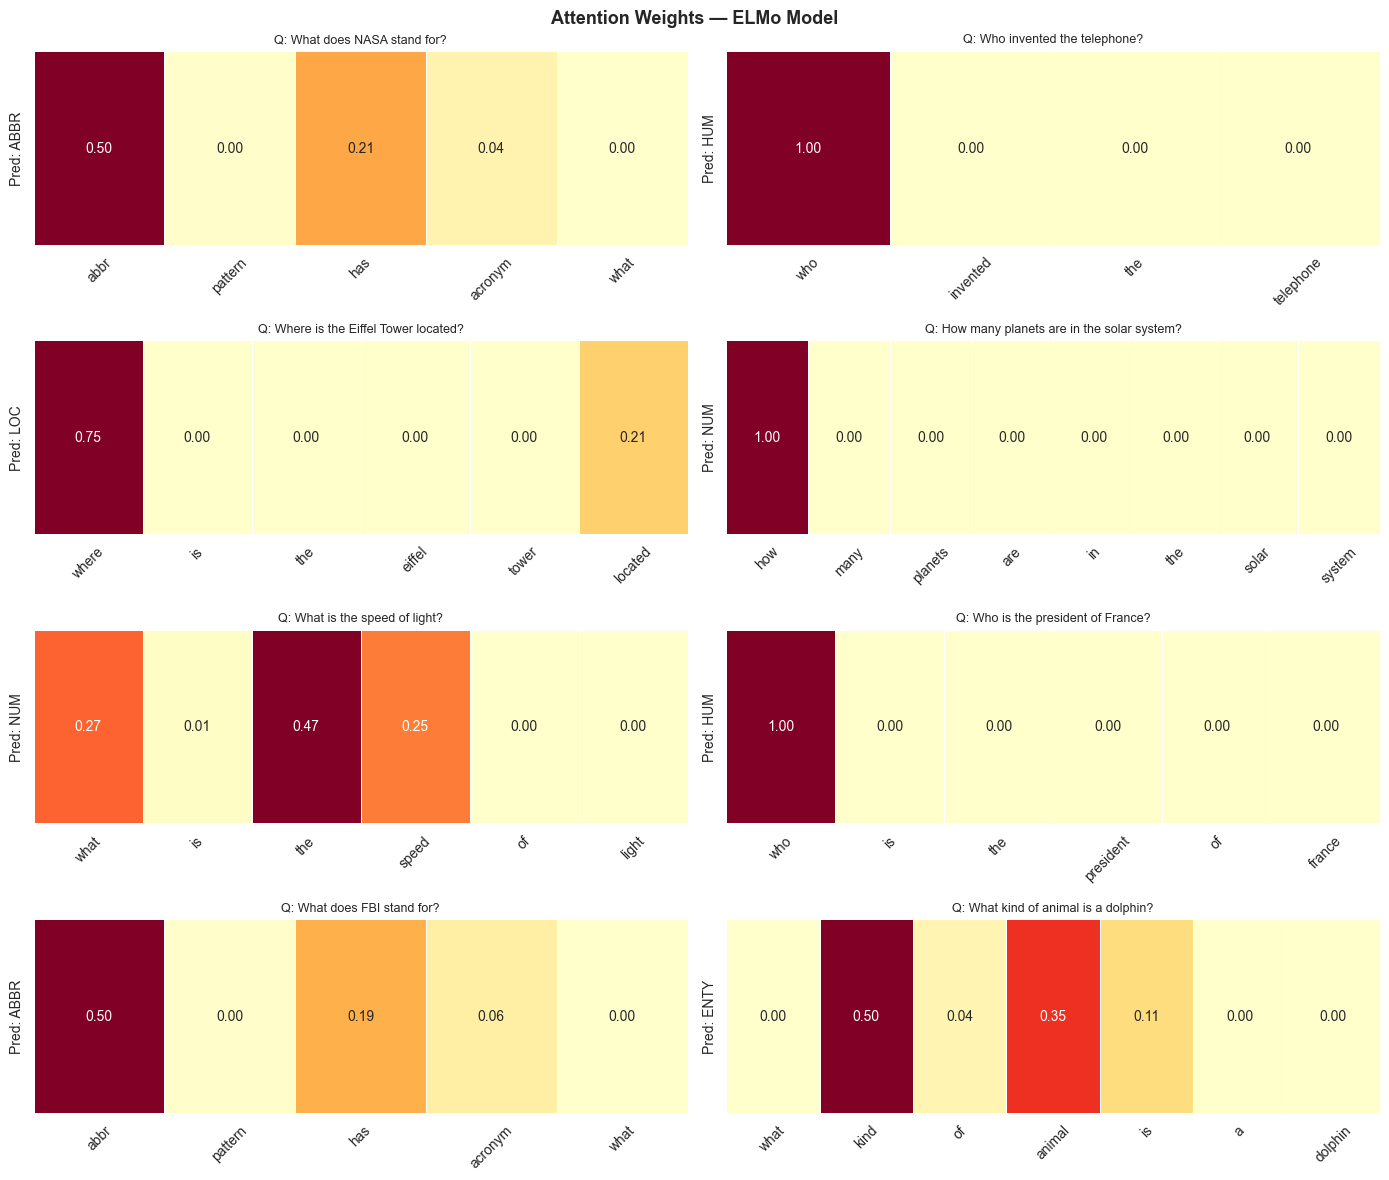

In [18]:
# ==========================================
#         ATTENTION HEATMAP
# ==========================================
def predict_with_attention(question):
    model2.eval()
    tokens   = pad_tokens(tokenize(preprocess_text(question)), MAX_LEN)
    char_ids = batch_to_ids([tokens]).to(device)
    with torch.no_grad():
        elmo_emb     = elmo(char_ids)['elmo_representations'][0]
        out, weights = model2(elmo_emb)
    pred     = out.argmax(1).item()
    weights  = weights.squeeze().cpu().numpy()
    real_len = min(len(question.split()), MAX_LEN)
    return label_names[pred], tokens[:real_len], weights[:real_len]

def plot_attention(questions, n_cols=2):
    n_rows = (len(questions) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
    axes = axes.flatten()
    for i, q in enumerate(questions):
        pred, tokens, weights = predict_with_attention(q)
        sns.heatmap(weights.reshape(1, -1), ax=axes[i], cmap='YlOrRd',
                    xticklabels=tokens, yticklabels=[f'Pred: {pred}'],
                    annot=True, fmt='.2f', linewidths=0.5, cbar=False)
        axes[i].set_title(f'Q: {q}', fontsize=9)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('Attention Weights — ELMo Model', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('model2_attention.png', dpi=150, bbox_inches='tight')
    plt.show()

demo_questions = [
    'What does NASA stand for?',
    'Who invented the telephone?',
    'Where is the Eiffel Tower located?',
    'How many planets are in the solar system?',
    'What is the speed of light?',
    'Who is the president of France?',
    'What does FBI stand for?',
    'What kind of animal is a dolphin?',
]
plot_attention(demo_questions)


## 13. Augmented Test — Kiểm tra ABBR với 40 câu mới

KẾT QUẢ AUGMENTED TEST (500 + 40 ABBR mới)
Test Accuracy : 0.9611 (96.11%)
F1 Macro      : 0.9640

F1 từng class:
  ABBR: 1.0000 (+0.0000)
  DESC: 0.9574 (+0.0000)
  ENTY: 0.9050 (+0.0000)
  HUM: 0.9624 (+0.0000)
  LOC: 0.9814 (+0.0000)
  NUM: 0.9780 (+0.0000)

              precision    recall  f1-score   support

        ABBR     1.0000    1.0000    1.0000        49
        DESC     0.9375    0.9783    0.9574       138
        ENTY     0.9529    0.8617    0.9050        94
         HUM     0.9412    0.9846    0.9624        65
         LOC     0.9875    0.9753    0.9814        81
         NUM     0.9737    0.9823    0.9780       113

    accuracy                         0.9611       540
   macro avg     0.9655    0.9637    0.9640       540
weighted avg     0.9614    0.9611    0.9607       540



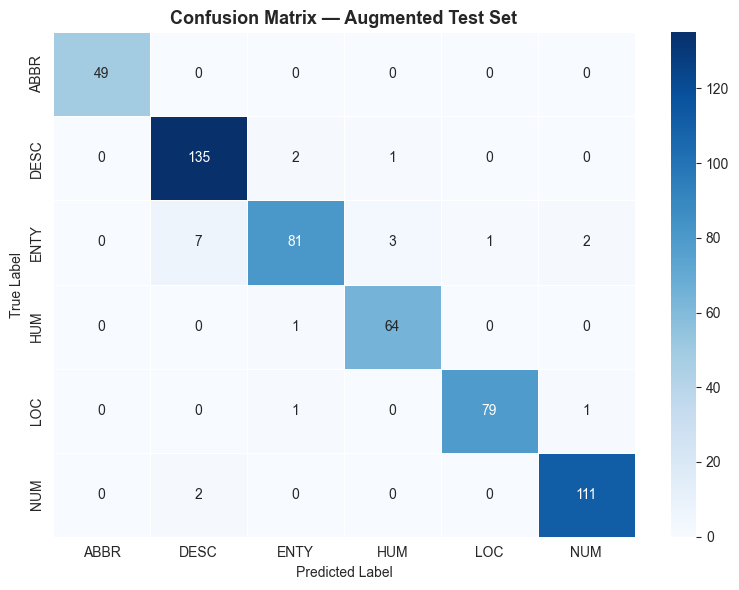

In [19]:
# ==========================================
#    AUGMENTED TEST SET — 40 ABBR mới
# ==========================================
extra_abbr = [
    ("What does CPU stand for?",             "ABBR"),
    ("Expand the abbreviation CPU.",          "ABBR"),
    ("What is CPU short for?",               "ABBR"),
    ("Give the full form of CPU.",           "ABBR"),
    ("Can you expand NASA?",                 "ABBR"),
    ("What is the full name of NASA?",       "ABBR"),
    ("HTML stands for what?",                "ABBR"),
    ("What does HTML mean?",                 "ABBR"),
    ("What is AI short for?",                "ABBR"),
    ("Please expand the acronym AI.",        "ABBR"),
    ("What does WHO stand for?",             "ABBR"),
    ("UN is short for what?",                "ABBR"),
    ("What is the expansion of USB?",        "ABBR"),
    ("Tell me the full form of USB.",        "ABBR"),
    ("RAM means what?",                      "ABBR"),
    ("What does RAM refer to in full?",      "ABBR"),
    ("Could you spell out PDF?",             "ABBR"),
    ("What is PDF an abbreviation for?",     "ABBR"),
    ("URL expands to what?",                 "ABBR"),
    ("What does URL stand for on the web?",  "ABBR"),
    ("Expand GDP.",                          "ABBR"),
    ("What is GDP short for?",               "ABBR"),
    ("What does ATM stand for?",             "ABBR"),
    ("VPN is an abbreviation for what?",     "ABBR"),
    ("What is CEO short for?",               "ABBR"),
    ("Expand the term CEO.",                 "ABBR"),
    ("FAQ stands for what?",                 "ABBR"),
    ("What does SMS stand for?",             "ABBR"),
    ("What is DIY short for?",               "ABBR"),
    ("Could you give me the long form of Wi-Fi?", "ABBR"),
    ("What do the initials FBI stand for?",  "ABBR"),
    ("What do the initials CIA stand for?",  "ABBR"),
    ("How do you expand PhD?",               "ABBR"),
    ("What is the full form of PhD?",        "ABBR"),
    ("What is UNESCO short for?",            "ABBR"),
    ("Can you tell me what ICU stands for?", "ABBR"),
    ("NICU stands for what exactly?",        "ABBR"),
    ("What is the long form of FAQ?",        "ABBR"),
    ("What does SQL stand for?",             "ABBR"),
    ("API is short for what?",               "ABBR"),
]

extra_true, extra_pred = [], []
for q, label in extra_abbr:
    pred_label, _, _ = predict_with_attention(q)
    extra_true.append(label_map[label])
    extra_pred.append(label_map[pred_label])

y_true_aug = np.concatenate([y_true2, extra_true])
y_pred_aug = np.concatenate([y_pred2, extra_pred])

acc_aug      = accuracy_score(y_true_aug, y_pred_aug)
f1_macro_aug = f1_score(y_true_aug, y_pred_aug, average='macro')
f1_per_aug   = f1_score(y_true_aug, y_pred_aug, average=None)
cm_aug       = confusion_matrix(y_true_aug, y_pred_aug)

print('=' * 60)
print('KẾT QUẢ AUGMENTED TEST (500 + 40 ABBR mới)')
print('=' * 60)
print(f'Test Accuracy : {acc_aug:.4f} ({acc_aug*100:.2f}%)')
print(f'F1 Macro      : {f1_macro_aug:.4f}')
print()
print('F1 từng class:')
for i, f1 in enumerate(f1_per_aug):
    delta = f1 - f1_per_class2[i]
    print(f'  {label_names[i]}: {f1:.4f} ({"+" if delta>=0 else ""}{delta:.4f})')

print()
print(classification_report(y_true_aug, y_pred_aug, target_names=label_names, digits=4))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, linewidths=0.5)
plt.title('Confusion Matrix — Augmented Test Set', fontsize=13, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('model2_confusion_aug.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. OOD Test — Kiểm tra học vẹt

In [20]:
# ==========================================
#    OOD TEST — Kiểm tra học vẹt ABBR
# ==========================================
ood_questions = [
    ("Could you spell out HVAC?",            "ABBR"),
    ("JPEG is short for what exactly?",      "ABBR"),
    ("Please define the acronym SONAR",      "ABBR"),
    ("What do the letters TASER represent?", "ABBR"),
    ("Give me the expansion of MPEG",        "ABBR"),
    ("What does INTERPOL stand for?",        "ABBR"),
    ("UNICEF is an abbreviation for what?",  "ABBR"),
    ("What is the full name of OPEC?",       "ABBR"),
    ("Expand the acronym SWAT",              "ABBR"),
    ("What does CAPTCHA mean?",              "ABBR"),
    ("Who invented the light bulb?",         "HUM"),
    ("Where is the Amazon river located?",   "LOC"),
    ("How many bones are in the human body?","NUM"),
    ("What is photosynthesis?",              "DESC"),
    ("What kind of animal is a platypus?",   "ENTY"),
]

print("=" * 60)
print("  OOD TEST — Kiểm tra học vẹt ABBR")
print("=" * 60)
print(f"{'Question':<45} {'True':>6} {'Pred':>6} {'OK':>4}")
print("-" * 60)

correct_abbr, abbr_total = 0, 0
correct_other, other_total = 0, 0

for q, true_label in ood_questions:
    pred_label, _, _ = predict_with_attention(q)
    ok = "✓" if pred_label == true_label else "✗"
    print(f"{q:<45} {true_label:>6} {pred_label:>6} {ok:>4}")
    if true_label == "ABBR":
        abbr_total += 1
        if pred_label == true_label: correct_abbr += 1
    else:
        other_total += 1
        if pred_label == true_label: correct_other += 1

print("=" * 60)
print(f"\nOOD ABBR Accuracy  : {correct_abbr}/{abbr_total} = {correct_abbr/abbr_total*100:.1f}%")
print(f"Other class Accuracy: {correct_other}/{other_total} = {correct_other/other_total*100:.1f}%")
print()
if correct_abbr/abbr_total >= 0.9:
    print("✅ Model học được pattern thật — KHÔNG học vẹt!")
elif correct_abbr/abbr_total >= 0.6:
    print("⚠️  Model học được một phần — còn phụ thuộc entity cụ thể")
else:
    print("❌ Model có dấu hiệu học vẹt — chỉ nhớ entity quen thuộc")


  OOD TEST — Kiểm tra học vẹt ABBR
Question                                        True   Pred   OK
------------------------------------------------------------
Could you spell out HVAC?                       ABBR   ABBR    ✓
JPEG is short for what exactly?                 ABBR   ABBR    ✓
Please define the acronym SONAR                 ABBR   ABBR    ✓
What do the letters TASER represent?            ABBR   ABBR    ✓
Give me the expansion of MPEG                   ABBR   ABBR    ✓
What does INTERPOL stand for?                   ABBR   ABBR    ✓
UNICEF is an abbreviation for what?             ABBR   ABBR    ✓
What is the full name of OPEC?                  ABBR   ABBR    ✓
Expand the acronym SWAT                         ABBR   ABBR    ✓
What does CAPTCHA mean?                         ABBR   ABBR    ✓
Who invented the light bulb?                     HUM    HUM    ✓
Where is the Amazon river located?               LOC    LOC    ✓
How many bones are in the human body?            NUM    NUM

## 15. So sánh Model 1 vs Model 2

       Metric Model 1 (CNN) Model 2 (BiLSTM+ELMo) Delta (M2-M1)
Test Accuracy        90.00%                95.80%       +0.0580
     F1 Macro        0.8864                0.9640       +0.0776
  F1 Weighted        0.8989                0.9575       +0.0586
    F1 - ABBR        0.8235                1.0000       +0.1765
    F1 - DESC        0.9073                0.9574       +0.0501
    F1 - ENTY        0.8092                0.9050       +0.0958
     F1 - HUM        0.9173                0.9624       +0.0451
     F1 - LOC        0.9125                0.9814       +0.0689
     F1 - NUM        0.9488                0.9780       +0.0292
 Tổng tham số     1,483,398             4,077,062             —


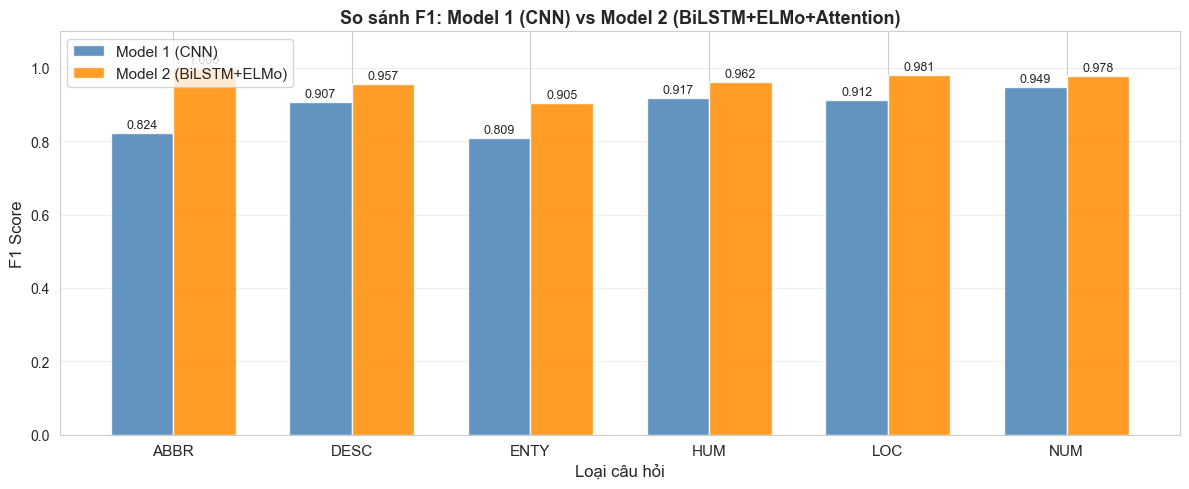

In [21]:
# ==========================================
#         SO SÁNH MODEL 1 vs MODEL 2
# ==========================================
acc1          = 0.9000
f1_macro1     = 0.8864
f1_weighted1  = 0.8989
f1_per_class1 = np.array([0.8235, 0.9073, 0.8092, 0.9173, 0.9125, 0.9488])
params_m1     = 1_483_398
params_m2     = sum(p.numel() for p in model2.parameters())

results_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'F1 Macro', 'F1 Weighted',
               'F1 - ABBR', 'F1 - DESC', 'F1 - ENTY', 'F1 - HUM', 'F1 - LOC', 'F1 - NUM',
               'Tổng tham số'],
    'Model 1 (CNN)': [f'{acc1*100:.2f}%', f'{f1_macro1:.4f}', f'{f1_weighted1:.4f}',
                      *[f'{v:.4f}' for v in f1_per_class1], f'{params_m1:,}'],
    'Model 2 (BiLSTM+ELMo)': [f'{acc2*100:.2f}%', f'{f1_macro2:.4f}', f'{f1_weighted2:.4f}',
                               *[f'{v:.4f}' for v in f1_per_class2], f'{params_m2:,}']
})
m1_vals = [acc1, f1_macro1, f1_weighted1] + list(f1_per_class1)
m2_vals = [acc2, f1_macro2, f1_weighted2] + list(f1_per_class2)
results_df['Delta (M2-M1)'] = [f'{m2-m1:+.4f}' if abs(m2-m1) > 0.0001 else '—'
                                for m1, m2 in zip(m1_vals, m2_vals)] + ['—']
print(results_df.to_string(index=False))

x = np.arange(len(label_names)); width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, f1_per_class1, width, label='Model 1 (CNN)',        color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, f1_per_class2, width, label='Model 2 (BiLSTM+ELMo)', color='darkorange', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Loại câu hỏi', fontsize=12); ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('So sánh F1: Model 1 (CNN) vs Model 2 (BiLSTM+ELMo+Attention)', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(label_names, fontsize=11)
ax.legend(fontsize=11); ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Demo Predictions

In [31]:
# ==========================================
#         DEMO PREDICTIONS
# ==========================================
test_questions = [
    ('What does NASA stand for?',          'ABBR'  ),
    ('Who invented the telephone?',           'HUM'),
    ('Where is the Eiffel Tower located?',    'LOC'),
    ('How many planets in the solar system?', 'NUM'),
    ('What is machine learning?',             'DESC'),
    ('What is your current address?',             'LOC'),
    ('What does FBI stand for?',              'ABBR'),
    ('What is DNA short for?',                'ABBR'),
    ('What kind of animal is a dolphin?',     'ENTY'),
    ('What is steel made of?',                'ENTY'),
    ('Could you spell out HVAC?',             'ABBR'),
    ("Tell me about the history of USA",       'DESC'),
]
print('=' * 65)
print(f'{"Question":<42} {"True":>6} {"Pred":>6} {"OK":>4}')
print('=' * 65)
correct = 0
for q, true_label in test_questions:
    pred_label, _, _ = predict_with_attention(q)
    ok = '✓' if pred_label == true_label else '✗'
    if pred_label == true_label: correct += 1
    print(f'{q:<42} {true_label:>6} {pred_label:>6} {ok:>4}')
print('=' * 65)
print(f'Demo accuracy: {correct}/{len(test_questions)} = {correct/len(test_questions)*100:.1f}%')


Question                                     True   Pred   OK
What does NASA stand for?                    ABBR   ABBR    ✓
Who invented the telephone?                   HUM    HUM    ✓
Where is the Eiffel Tower located?            LOC    LOC    ✓
How many planets in the solar system?         NUM    NUM    ✓
What is machine learning?                    DESC   DESC    ✓
What is your current address?                 LOC    LOC    ✓
What does FBI stand for?                     ABBR   ABBR    ✓
What is DNA short for?                       ABBR   ABBR    ✓
What kind of animal is a dolphin?            ENTY   ENTY    ✓
What is steel made of?                       ENTY   ENTY    ✓
Could you spell out HVAC?                    ABBR   ABBR    ✓
Tell me about the history of USA             DESC   DESC    ✓
Demo accuracy: 12/12 = 100.0%
